## 07 Cohort Analysis - Retention & Lifetime Value

**Input:** 
- data/ventas_clean.csv
- data/rfm_segemnts.csv

**Business questions:** Which acquisition cohorts are most valuable?  
Are repeat buyers structurally different from one-time buyers?  
And under high inflation, how do we separate nominal LTV growth from real retention?

## Setup

In [ ]:
import os
import pathlib
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

ROOT = pathlib.Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

C = dict(
    bg='#0A0E17', surface='#111827', surf2='#1A2235',
    border='#1E2D45', accent='#00E5A0', gold='#F5C842',
    red='#FF4D6A', blue='#4D9FFF', orange='#E8883A',
    purple='#A78BFA', text='#E8EDF5', muted='#6B7A99',
)
YEAR_COLORS = {2023: C['blue'], 2024: C['accent'], 2025: C['gold'], 2026: C['orange']}
SEG_COLORS = {
    'VIP': C['gold'], 'Loyal': C['accent'], 'Potential': C['blue'],
    'At Risk': C['red'], 'Occasional': C['purple'], 'Lost': C['muted'],
}

mpl.rcParams.update({
    'figure.facecolor': C['bg'], 'axes.facecolor': C['surface'],
    'axes.edgecolor': C['border'], 'axes.labelcolor': C['muted'],
    'axes.titlecolor': C['text'], 'text.color': C['text'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': C['border'], 'grid.linewidth': 0.6,
    'xtick.color': C['muted'], 'ytick.color': C['muted'],
    'font.family': 'DejaVu Sans',
})

os.makedirs(ROOT / 'plots', exist_ok=True)

df = pd.read_csv(ROOT / 'data' / 'ventas_clean.csv', parse_dates=['date'])
rfm = pd.read_csv(ROOT / 'data' / 'rfm_segments.csv')

print(f'Orders: {len(df):,}')
print(f'SKUs: {rfm["sku_id"].nunique():,}')   
print(f'Segments: {sorted(rfm["segment"].unique())}')


Orders: 353
SKUs: 120
Segments: ['At Risk', 'Lost', 'Loyal', 'Occasional', 'Potential', 'VIP']


## Cohort Table

In [2]:
# First sale date per item_id
first_sale = (
    df.groupby('item_id')
    .agg(
        first_date = ('date', 'min'),
        last_date = ('date', 'max'),
        total_orders = ('order_id', 'nunique'),
        total_revenue = ('gross_revenue', 'sum'),
        revenue_real = ('gross_revenue_real', 'sum'),
        avg_ticket = ('unit_price', 'mean'),
        n_provinces = ('province', 'nunique'),
    )
    .reset_index()
    .dropna(subset=['item_id'])
)

# Cohort = year-quarter of first sale
first_sale['cohort_q'] = first_sale['first_date'].dt.to_period('Q')
first_sale['cohort_year'] = first_sale['first_date'].dt.year
first_sale['active_months'] = (
    (first_sale['last_date'] - first_sale['first_date']).dt.days / 30.44
).round(1)
first_sale['is_repeat'] = first_sale['total_orders'] > 1

# Merge with RFM segments on item_id 
cohort_df = first_sale.merge(
    rfm[['item_id', 'segment', 'R_score', 'F_score', 'M_score']],
    on='item_id',
    how='left',
)

print(f'Cohort table: {len(cohort_df):,} SKUs across {cohort_df["cohort_q"].nunique()} quarters')
print(f'Segment match rate: {cohort_df["segment"].notna().mean():.1%}')
print()
print('SKUs per cohort quarter:')
print(cohort_df.groupby('cohort_q').size().to_string())


Cohort table: 120 SKUs across 12 quarters
Segment match rate: 100.0%

SKUs per cohort quarter:
cohort_q
2023Q1    36
2023Q2    17
2023Q3    25
2023Q4    10
2024Q1    11
2024Q2     5
2024Q3     2
2024Q4     1
2025Q1     5
2025Q2     2
2025Q3     3
2026Q1     3
Freq: Q-DEC


## Acquisition Volume by Cohort

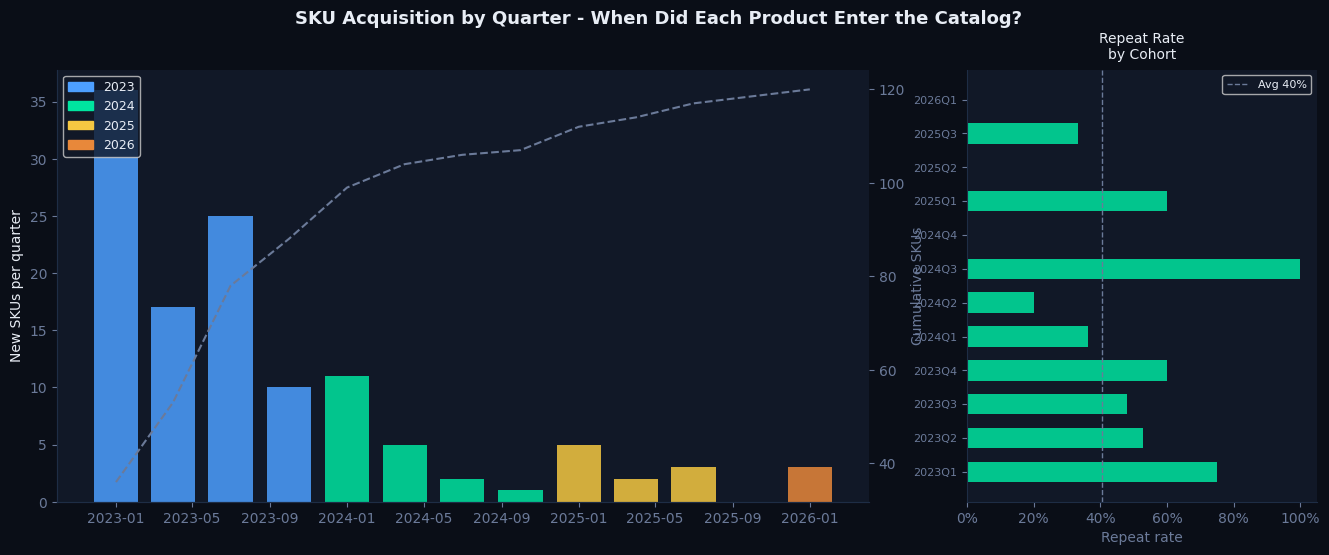

Peak acquisition quarter: 2023Q1 (36 SKUs)
Best repeat rate cohort: 2024Q3 (100.0%)


In [3]:
by_quarter = (
    cohort_df.groupby('cohort_q')
    .agg(
        n_skus = ('item_id', 'count'),
        repeat_rate = ('is_repeat', 'mean'),
        avg_revenue = ('revenue_real', 'mean'),
        total_revenue = ('revenue_real', 'sum'),
    )
    .reset_index()
)
by_quarter['date'] = by_quarter['cohort_q'].dt.to_timestamp()
by_quarter['cumulative']= by_quarter['n_skus'].cumsum()
by_quarter['year'] = by_quarter['date'].dt.year

fig = plt.figure(figsize=(14, 6), facecolor=C['bg'])
fig.text(0.5, 0.97, 'SKU Acquisition by Quarter - When Did Each Product Enter the Catalog?',
         ha='center', va='top', fontsize=13, fontweight='bold', color=C['text'])

ax1 = fig.add_axes([0.07, 0.15, 0.58, 0.72])
ax2 = ax1.twinx()

bar_colors = [YEAR_COLORS.get(y, C['muted']) for y in by_quarter['year']]
ax1.bar(by_quarter['date'], by_quarter['n_skus'], width=70,
        color=bar_colors, alpha=0.85, zorder=2)
ax2.plot(by_quarter['date'], by_quarter['cumulative'],
         color=C['muted'], linewidth=1.5, linestyle='--', label='Cumulative')

ax1.set_ylabel('New SKUs per quarter', color=C['text'])
ax2.set_ylabel('Cumulative SKUs', color=C['muted'])
ax1.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax1.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax1.spines[sp].set_color(C['border'])

patches = [mpatches.Patch(color=c, label=str(y)) for y,c in YEAR_COLORS.items()]
ax1.legend(handles=patches, fontsize=9, loc='upper left')

ax3 = fig.add_axes([0.72, 0.15, 0.25, 0.72])
colors_rr = [C['accent'] if r >= 0.15 else C['red'] for r in by_quarter['repeat_rate']]
ax3.barh(range(len(by_quarter)), by_quarter['repeat_rate'],
         color=colors_rr, alpha=0.85, height=0.6)
ax3.set_yticks(range(len(by_quarter)))
ax3.set_yticklabels([str(q) for q in by_quarter['cohort_q']], fontsize=8)
ax3.axvline(by_quarter['repeat_rate'].mean(), color=C['muted'],
            linewidth=1, linestyle='--', label=f'Avg {by_quarter["repeat_rate"].mean():.0%}')
ax3.set_xlabel('Repeat rate')
ax3.set_title('Repeat Rate\nby Cohort', fontsize=10, pad=8)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax3.legend(fontsize=8)
ax3.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax3.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax3.spines[sp].set_color(C['border'])

plt.savefig(ROOT / 'plots' / '29_cohort_acquisition.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

peak_q = by_quarter.loc[by_quarter['n_skus'].idxmax(), 'cohort_q']
best_rr = by_quarter.loc[by_quarter['repeat_rate'].idxmax(), 'cohort_q']
print(f'Peak acquisition quarter: {peak_q} ({by_quarter["n_skus"].max()} SKUs)')
print(f'Best repeat rate cohort: {best_rr} ({by_quarter["repeat_rate"].max():.1%})')

## LTV by Cohort - Nominal vs Real

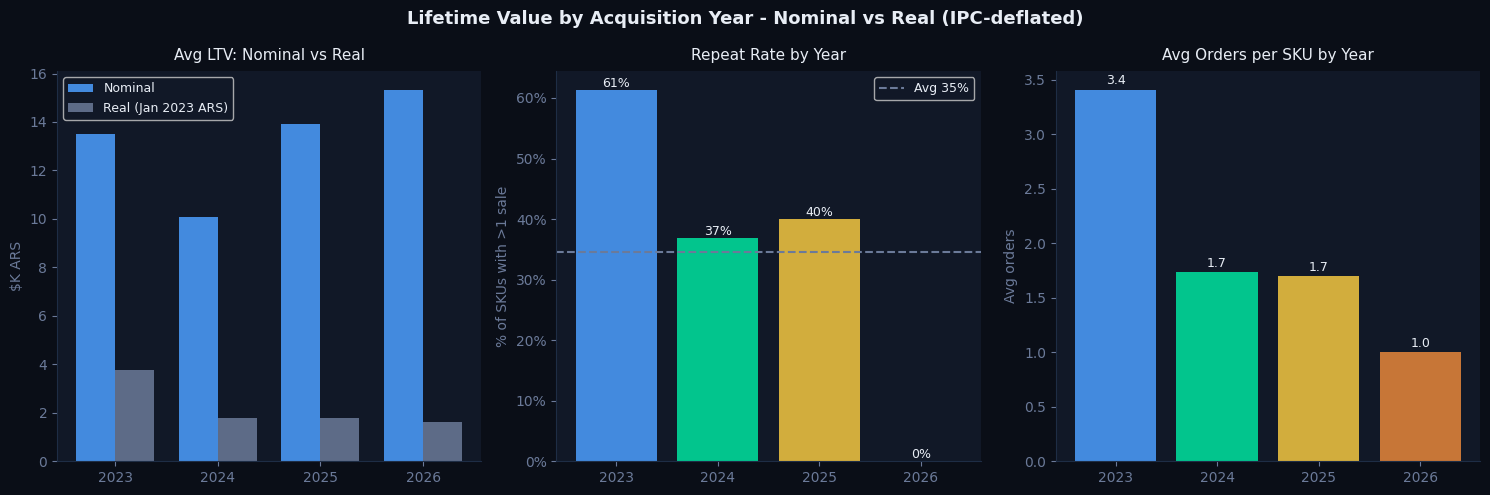

LTV Summary by Year:
 cohort_year  n_skus  avg_ltv_nom  avg_ltv_real  repeat_rate  avg_orders
        2023      88      13496.0        3768.0          1.0         3.0
        2024      19      10080.0        1803.0          0.0         2.0
        2025      10      13928.0        1800.0          0.0         2.0
        2026       3      15332.0        1606.0          0.0         1.0


In [4]:
ltv_by_year = (
    cohort_df.groupby('cohort_year')
    .agg(
        n_skus = ('item_id', 'count'),
        avg_ltv_nom = ('total_revenue', 'mean'),
        avg_ltv_real = ('revenue_real', 'mean'),
        med_ltv_nom = ('total_revenue', 'median'),
        med_ltv_real = ('revenue_real', 'median'),
        repeat_rate = ('is_repeat', 'mean'),
        avg_orders = ('total_orders', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=C['bg'])
fig.suptitle('Lifetime Value by Acquisition Year - Nominal vs Real (IPC-deflated)',
             fontsize=13, fontweight='bold', color=C['text'])

years = ltv_by_year['cohort_year'].tolist()
x = np.arange(len(years))
colors = [YEAR_COLORS.get(y, C['muted']) for y in years]
w = 0.38

# Panel 1: LTV nominal vs real
ax = axes[0]
ax.bar(x - w/2, ltv_by_year['avg_ltv_nom'] / 1e3, width=w, color=C['blue'], alpha=0.85, label='Nominal')
ax.bar(x + w/2, ltv_by_year['avg_ltv_real'] / 1e3, width=w, color=C['muted'], alpha=0.85, label='Real (Jan 2023 ARS)')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_title('Avg LTV: Nominal vs Real', fontsize=11, pad=8)
ax.set_ylabel('$K ARS')
ax.legend(fontsize=9)
ax.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax.spines[sp].set_color(C['border'])

# Panel 2: Repeat rate by year
ax = axes[1]
bars = ax.bar(x, ltv_by_year['repeat_rate'], color=colors, alpha=0.85)
ax.axhline(ltv_by_year['repeat_rate'].mean(), color=C['muted'],
           linewidth=1.5, linestyle='--', label=f'Avg {ltv_by_year["repeat_rate"].mean():.0%}')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_title('Repeat Rate by Year', fontsize=11, pad=8)
ax.set_ylabel('% of SKUs with >1 sale')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, ltv_by_year.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{row["repeat_rate"]:.0%}', ha='center', fontsize=9)
ax.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax.spines[sp].set_color(C['border'])

# Panel 3: Avg orders per SKU by year
ax = axes[2]
ax.bar(x, ltv_by_year['avg_orders'], color=colors, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_title('Avg Orders per SKU by Year', fontsize=11, pad=8)
ax.set_ylabel('Avg orders')
for bar, (_, row) in zip(ax.patches, ltv_by_year.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["avg_orders"]:.1f}', ha='center', fontsize=9)
ax.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax.spines[sp].set_color(C['border'])

plt.tight_layout()
plt.savefig(ROOT / 'plots' / '30_ltv_by_cohort.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

print('LTV Summary by Year:')
print(ltv_by_year[['cohort_year','n_skus','avg_ltv_nom','avg_ltv_real','repeat_rate','avg_orders']]
      .round(0).to_string(index=False))

## Retention Heatmap

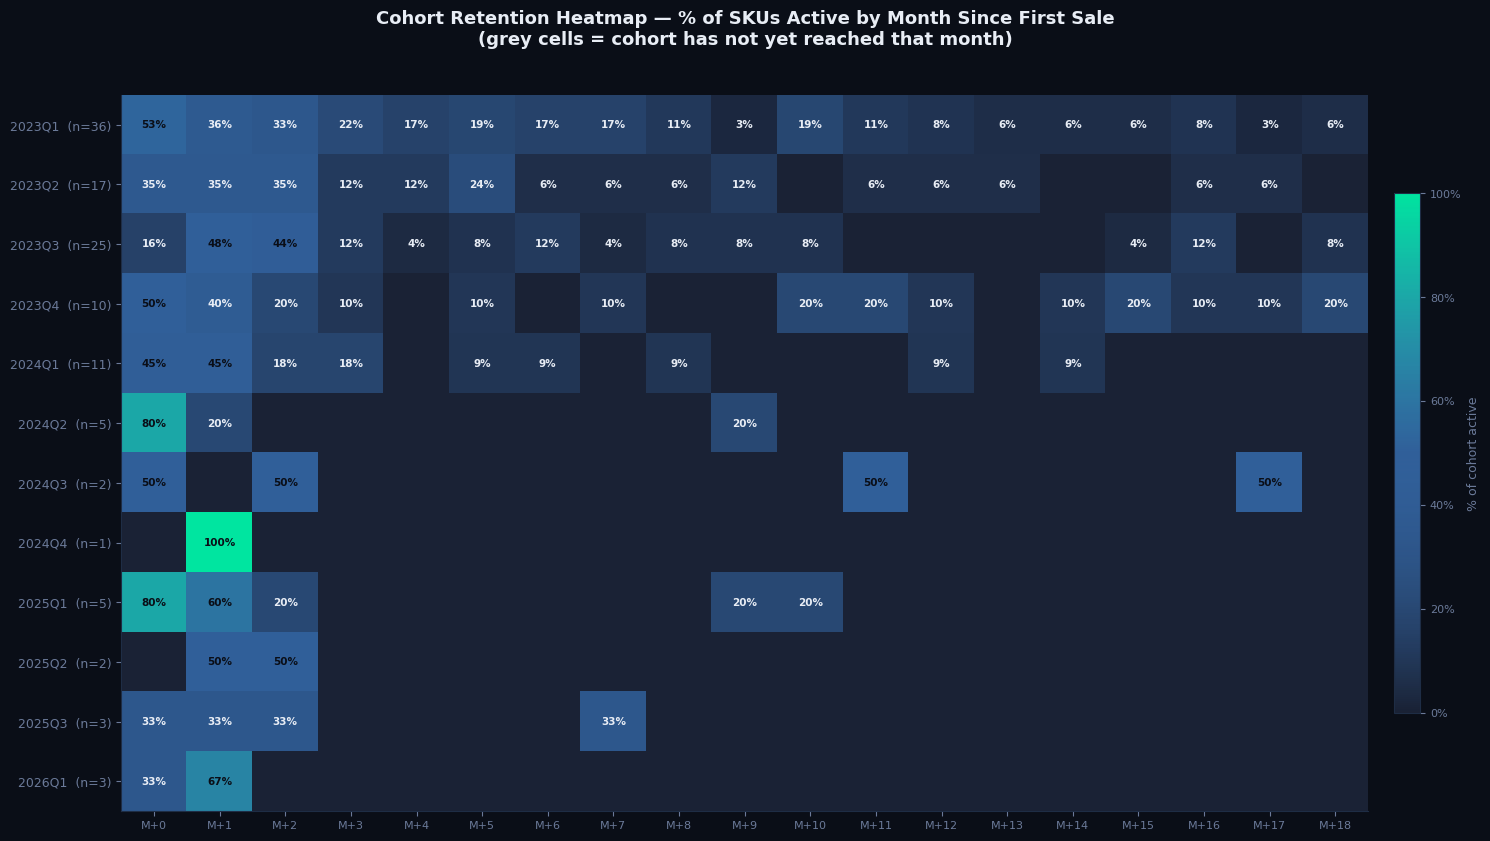

In [5]:
item_months = (
    df.groupby(['item_id', df['date'].dt.to_period('M')])
    .size()
    .reset_index()
    .rename(columns={'date': 'sale_month', 0: 'n_sales'})
)

item_months = item_months.merge(
    cohort_df[['item_id', 'cohort_q']], on='item_id', how='left'
).dropna(subset=['cohort_q'])

# Months since cohort start 
item_months['cohort_start_m'] = item_months['cohort_q'].dt.to_timestamp().dt.to_period('M')
item_months['months_since'] = (
    item_months['sale_month'] - item_months['cohort_start_m']
).apply(lambda x: x.n).clip(lower=0)

# Retention: % of cohort with at least 1 sale at month N
cohort_sizes = cohort_df.groupby('cohort_q').size().to_dict()

retention_pivot = (
    item_months[item_months['months_since'] <= 18]
    .groupby(['cohort_q', 'months_since'])
    .agg(active=('item_id', 'nunique'))
    .reset_index()
)
retention_pivot['cohort_size'] = retention_pivot['cohort_q'].map(cohort_sizes)
retention_pivot['retention'] = retention_pivot['active'] / retention_pivot['cohort_size']

heatmap_data = retention_pivot.pivot(
    index='cohort_q', columns='months_since', values='retention'
).fillna(np.nan)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'ret', [C['surf2'], C['blue'] + '88', C['accent']], N=256
)
cmap.set_bad(color='#1A2235')   

fig, ax = plt.subplots(figsize=(15, max(5, len(heatmap_data)*0.6 + 1)), facecolor=C['bg'])
fig.suptitle('Cohort Retention Heatmap — % of SKUs Active by Month Since First Sale\n'
             '(grey cells = cohort has not yet reached that month)',
             fontsize=13, fontweight='bold', color=C['text'], y=1.02)

im = ax.imshow(heatmap_data.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(heatmap_data.shape[1]))
ax.set_xticklabels([f'M+{i}' for i in heatmap_data.columns], fontsize=8)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(
    [f'{q}  (n={cohort_sizes.get(q,0)})' for q in heatmap_data.index],
    fontsize=9
)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        if not np.isnan(val) and val > 0:
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=7.5, fontweight='bold',
                    color=C['bg'] if val > 0.4 else C['text'])

cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.ax.tick_params(colors=C['muted'], labelsize=8)
cbar.set_label('% of cohort active', color=C['muted'], fontsize=9)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0%}'))

ax.set_facecolor(C['surface'])
plt.tight_layout()
plt.savefig(ROOT / 'plots' / '31_retention_heatmap.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()


## Repeat vs One-Time Buyer Profile

In [6]:
one_time = cohort_df[cohort_df['total_orders'] == 1]
repeat = cohort_df[cohort_df['total_orders'] >  1]

def _rfm_mean(df_sub, col):
    return f'{df_sub[col].mean():.2f}' if col in df_sub.columns else 'N/A'

profile = pd.DataFrame({
    'Metric': [
        'Count (SKUs)',
        'Avg total revenue (ARS)',
        'Median total revenue (ARS)',
        'Avg orders',
        'Avg active months',
        'Avg provinces reached',
        'Avg R score',
        'Avg F score',
        'Avg M score',
    ],
    'One-time': [
        f'{len(one_time):,}',
        f'${one_time["total_revenue"].mean():,.0f}',
        f'${one_time["total_revenue"].median():,.0f}',
        f'{one_time["total_orders"].mean():.1f}',
        f'{one_time["active_months"].mean():.1f} months',
        f'{one_time["n_provinces"].mean():.1f}',
        _rfm_mean(one_time, 'R_score'),
        _rfm_mean(one_time, 'F_score'),
        _rfm_mean(one_time, 'M_score'),
    ],
    'Repeat': [
        f'{len(repeat):,}',
        f'${repeat["total_revenue"].mean():,.0f}',
        f'${repeat["total_revenue"].median():,.0f}',
        f'{repeat["total_orders"].mean():.1f}',
        f'{repeat["active_months"].mean():.1f} months',
        f'{repeat["n_provinces"].mean():.1f}',
        _rfm_mean(repeat, 'R_score'),
        _rfm_mean(repeat, 'F_score'),
        _rfm_mean(repeat, 'M_score'),
    ],
})

print(profile.to_string(index=False))

ltv_multiplier = repeat['total_revenue'].median() / one_time['total_revenue'].median()
print(f'\nRepeat buyer LTV multiplier: {ltv_multiplier:.1f}x vs one-time (median)')


                    Metric   One-time      Repeat
              Count (SKUs)         55          65
   Avg total revenue (ARS)     $3,868     $20,796
Median total revenue (ARS)     $2,399     $13,800
                Avg orders        1.0         4.6
         Avg active months 0.0 months 15.5 months
     Avg provinces reached        0.9         2.3
               Avg R score       1.98        2.94
               Avg F score       1.00        2.38
               Avg M score       1.73        3.12

Repeat buyer LTV multiplier: 5.8x vs one-time (median)


## Revenue Concentration - Pareto by Segment

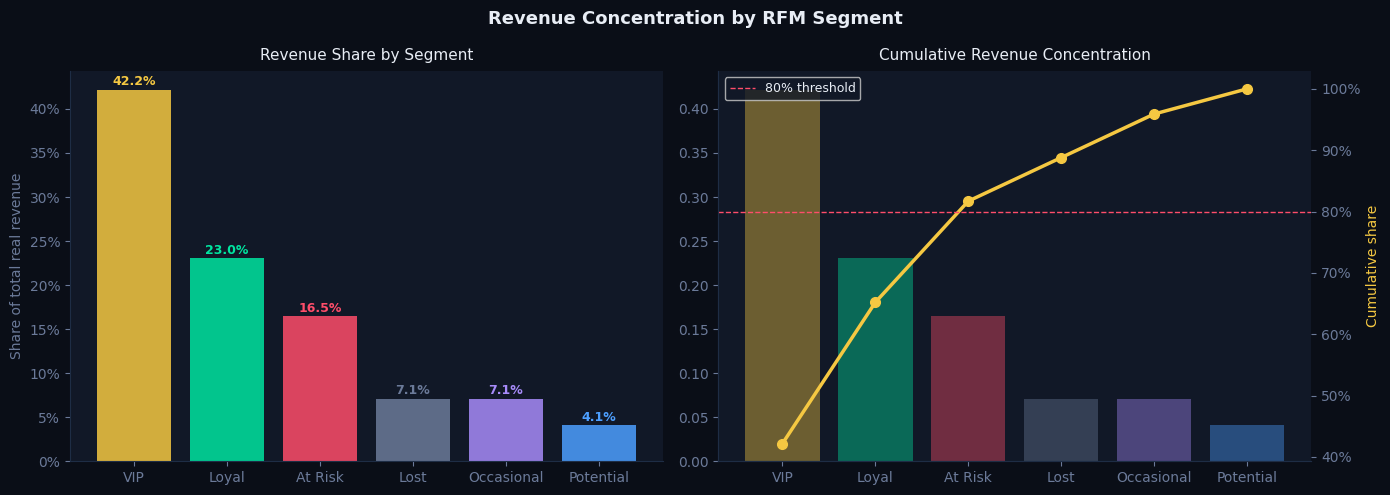

   segment  n_skus  rev_share  avg_ltv  rep_rate
       VIP      17      0.422 9645.038       1.0
     Loyal      29      0.230 3086.835       1.0
   At Risk      19      0.165 3371.150       1.0
      Lost      22      0.071 1254.402       0.0
Occasional      19      0.071 1452.116       0.0
 Potential      14      0.041 1138.781       0.0


In [7]:
if 'segment' in cohort_df.columns:
    seg_rev = (
        cohort_df.groupby('segment')
        .agg(
            n_skus = ('item_id', 'count'),
            revenue = ('revenue_real', 'sum'),
            avg_ltv = ('revenue_real', 'mean'),
            rep_rate = ('is_repeat', 'mean'),
        )
        .reset_index()
        .sort_values('revenue', ascending=False)
    )
    seg_rev['rev_share'] = seg_rev['revenue'] / seg_rev['revenue'].sum()
    seg_rev['cum_share'] = seg_rev['rev_share'].cumsum()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=C['bg'])
    fig.suptitle('Revenue Concentration by RFM Segment',
                 fontsize=13, fontweight='bold', color=C['text'])

    bar_colors = [SEG_COLORS.get(s, C['muted']) for s in seg_rev['segment']]
    bars = ax1.bar(seg_rev['segment'], seg_rev['rev_share'],
                   color=bar_colors, alpha=0.85)
    ax1.set_title('Revenue Share by Segment', fontsize=11, pad=8)
    ax1.set_ylabel('Share of total real revenue')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0%}'))
    for bar, (_, row) in zip(bars, seg_rev.iterrows()):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{row["rev_share"]:.1%}', ha='center', fontsize=9,
                 color=SEG_COLORS.get(row['segment'], C['muted']), fontweight='bold')
    ax1.set_facecolor(C['surface'])
    for sp in ['top','right']:
        ax1.spines[sp].set_visible(False)
    for sp in ['left','bottom']:
        ax1.spines[sp].set_color(C['border'])

    # Pareto cumulative
    ax2.bar(seg_rev['segment'], seg_rev['rev_share'], color=bar_colors, alpha=0.4)
    ax2_twin = ax2.twinx()
    ax2_twin.plot(seg_rev['segment'], seg_rev['cum_share'],
                  color=C['gold'], linewidth=2.5, marker='o', markersize=7)
    ax2_twin.axhline(0.80, color=C['red'], linewidth=1, linestyle='--', label='80% threshold')
    ax2_twin.set_ylabel('Cumulative share', color=C['gold'])
    ax2_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0%}'))
    ax2_twin.legend(fontsize=9)
    ax2.set_title('Cumulative Revenue Concentration', fontsize=11, pad=8)
    ax2.set_facecolor(C['surface'])
    for sp in ['top','right']:
        ax2.spines[sp].set_visible(False)
    for sp in ['left','bottom']:
        ax2.spines[sp].set_color(C['border'])

    plt.tight_layout()
    plt.savefig(ROOT / 'plots' / '32_revenue_concentration.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
    plt.show()

    print(seg_rev[['segment','n_skus','rev_share','avg_ltv','rep_rate']].round(3).to_string(index=False))
else:
    print('Segment column not found in cohort_df - check rfm merge.')

## LTV Projection

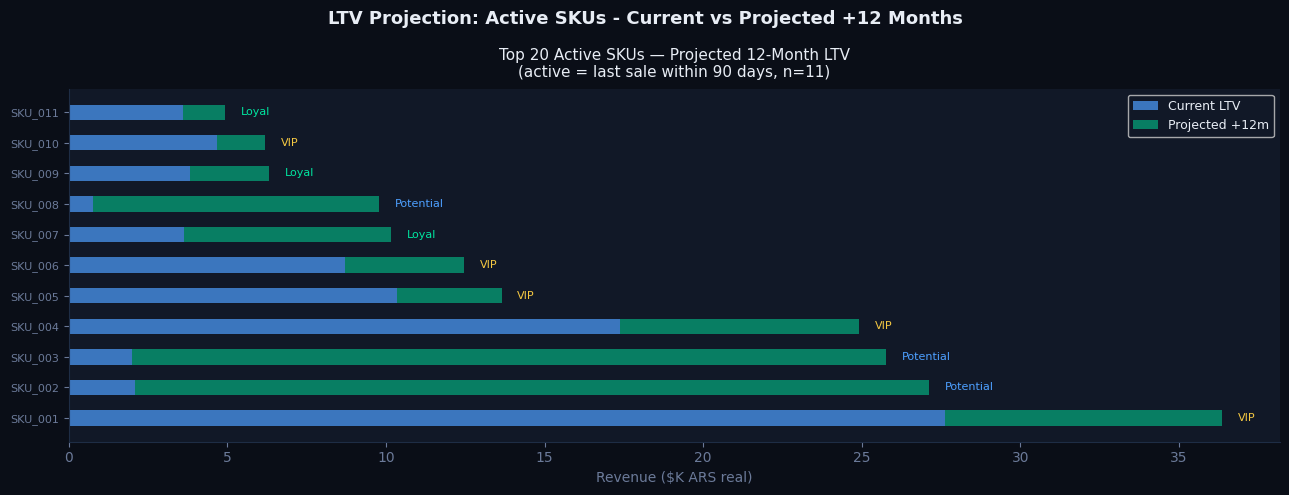

Active SKUs (last sale <= 90d): 11
Inactive SKUs: 109
Total projected 12m revenue: $177,607 ARS real


In [8]:
# LTV projection: monthly revenue rate × remaining expected months
cohort_df['monthly_rate'] = (
    cohort_df['revenue_real'] / cohort_df['active_months'].clip(lower=1)
)

REF_DATE = df['date'].max()
cohort_df['days_since_last'] = (REF_DATE - cohort_df['last_date']).dt.days
active_mask = cohort_df['days_since_last'] <= 90

active = cohort_df[active_mask].copy()
inactive = cohort_df[~active_mask].copy()

active['projected_ltv_12m'] = active['revenue_real'] + active['monthly_rate'] * 12

fig, ax = plt.subplots(figsize=(13, 5), facecolor=C['bg'])
fig.suptitle('LTV Projection: Active SKUs - Current vs Projected +12 Months',
             fontsize=13, fontweight='bold', color=C['text'])

active_sorted = active.sort_values('projected_ltv_12m', ascending=False).head(20)
y = np.arange(len(active_sorted))

ax.barh(y, active_sorted['revenue_real'] / 1e3,
        color=C['blue'], alpha=0.7, height=0.5, label='Current LTV')
ax.barh(y, (active_sorted['projected_ltv_12m'] - active_sorted['revenue_real']) / 1e3,
        left=active_sorted['revenue_real'] / 1e3,
        color=C['accent'], alpha=0.5, height=0.5, label='Projected +12m')

for i, (_, row) in enumerate(active_sorted.iterrows()):
    seg = row.get('segment', '')
    ax.text(row['projected_ltv_12m'] / 1e3 + 0.5, i,
            f'{seg}', va='center', fontsize=8, color=SEG_COLORS.get(seg, C['muted']))

ax.set_yticks(y)
ax.set_yticklabels([f'SKU_{i+1:03d}' for i in range(len(active_sorted))], fontsize=8)
ax.set_xlabel('Revenue ($K ARS real)')
ax.set_title(f'Top 20 Active SKUs — Projected 12-Month LTV\n(active = last sale within 90 days, n={len(active)})', fontsize=11, pad=8)
ax.legend(fontsize=9)
ax.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax.spines[sp].set_color(C['border'])

plt.tight_layout()
plt.savefig(ROOT / 'plots' / '33_ltv_projection.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

print(f'Active SKUs (last sale <= 90d): {len(active)}')
print(f'Inactive SKUs: {len(inactive)}')
print(f'Total projected 12m revenue: ${active["projected_ltv_12m"].sum():,.0f} ARS real')

## Key Findings & Actions

In [9]:
print('COHORT ANALYSIS - KEY FINDINGS')

total = len(cohort_df)
n_repeat = cohort_df['is_repeat'].sum()
n_one_time = total - n_repeat
ltv_mult = repeat['total_revenue'].median() / one_time['total_revenue'].median() if len(one_time) > 0 and len(repeat) > 0 else 0

print('\n[ACQUISITION]')
print(f'Total SKUs: {total}')
print(f'One-time sellers: {n_one_time} ({n_one_time/total:.0%})')
print(f'Repeat sellers: {n_repeat} ({n_repeat/total:.0%})')
print(f'Best repeat cohort: {best_rr}')

print('\n[LTV]')
print(f'Repeat LTV multiplier: {ltv_mult:.1f}x vs one-time (median)')
print('Real LTV trend: check chart - inflation-adjusted tells the true story')

if 'segment' in cohort_df.columns:
    top_seg = seg_rev.iloc[0]
    print('\n[CONCENTRATION]')
    print(f'Top segment: {top_seg["segment"]} ({top_seg["rev_share"]:.1%} of revenue)')
    top2_share = seg_rev.iloc[:2]["rev_share"].sum()
    print(f'Top 2 segments: {top2_share:.1%} of total revenue')

print('\n[ACTIONS]')
print('1. Contact repeat-eligible SKUs within 30d of last sale')
print(f'-> focus on {best_rr} cohort pattern: what drove its {by_quarter.loc[by_quarter["cohort_q"]==best_rr, "repeat_rate"].values[0]:.0%} repeat rate?')
print('2. Reactivation campaign for inactive SKUs (days_since_last > 90)')
print(f'-> {len(inactive)} SKUs at risk - {inactive["revenue_real"].sum():,.0f} ARS real historical revenue')
print('3. Protect VIP/Loyal segment - they drive disproportionate revenue')
print('4. Track real LTV, not nominal - inflation masks retention problems')

COHORT ANALYSIS - KEY FINDINGS

[ACQUISITION]
Total SKUs: 120
One-time sellers: 55 (46%)
Repeat sellers: 65 (54%)
Best repeat cohort: 2024Q3

[LTV]
Repeat LTV multiplier: 5.8x vs one-time (median)
Real LTV trend: check chart - inflation-adjusted tells the true story

[CONCENTRATION]
Top segment: VIP (42.2% of revenue)
Top 2 segments: 65.2% of total revenue

[ACTIONS]
1. Contact repeat-eligible SKUs within 30d of last sale
-> focus on 2024Q3 cohort pattern: what drove its 100% repeat rate?
2. Reactivation campaign for inactive SKUs (days_since_last > 90)
-> 109 SKUs at risk - 304,078 ARS real historical revenue
3. Protect VIP/Loyal segment - they drive disproportionate revenue
4. Track real LTV, not nominal - inflation masks retention problems
